# T2.2 — Multilingual Grant & Tender Matcher
## Evaluation Notebook: MRR@5, Recall@5, Confusion Analysis

**Challenge:** AIMS KTT Hackathon · T2.2  
**Date:** April 2026

---

This notebook:
1. Generates data (if not already present)
2. Runs the matcher across all 10 profiles
3. Computes MRR@5 and Recall@5 vs. `gold_matches.csv`
4. Displays per-profile score breakdown
5. Shows 3 confusion cases with root-cause analysis

In [ ]:
# # ── 0. Install dependencies if needed ─────────────────────────────────────────
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
#     'sentence-transformers', 'scikit-learn', 'langdetect',
#     'beautifulsoup4', 'pdfplumber', 'pandas', 'matplotlib', 'seaborn'])
# print('✅ Dependencies ready')

In [ ]:
# import os
# from getpass import getpass

# hf_token = getpass('Enter your Hugging Face token: ')
# os.environ['HUGGINGFACE_TOKEN'] = hf_token
# print('✅ HF token set')

In [3]:
# ── 1. Generate data ───────────────────────────────────────────────────────────
import os
if not os.path.exists('profiles.json') or not os.path.exists('tenders'):
    print('Generating synthetic data …')
    exec(open('generate_data.py').read())
else:
    print('✅ Data already present')

✅ Data already present


In [4]:
# ── 2. Run evaluation ──────────────────────────────────────────────────────────
from evaluate import evaluate, find_confusion_cases

results, metrics = evaluate(topk=5)

print('\n📊 Global Metrics')
print(f"  MRR@5    : {metrics['MRR@5']}")
print(f"  Recall@5 : {metrics['Recall@5']}")
print(f"  Profiles : {metrics['n_profiles']}")

c:\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2086.67it/s]


✅ Using multilingual embeddings (MiniLM-L12-v2)
  📐 Encoding 40 tenders with MiniLM … done

📊 Global Metrics
  MRR@5    : 0.95
  Recall@5 : 0.7667
  Profiles : 10


In [8]:
# ── 3. Per-profile results table ───────────────────────────────────────────────
import pandas as pd

rows = []
for r in results:
    rows.append({
        'Profile': r['profile_id'],
        'Sector': r['sector'],
        'Country': r['country'],
        'Gold Matches': ', '.join(r['relevant']),
        'Top Predicted': r['predicted'][0] if r['predicted'] else '',
        'Hits': r['hits'],
        'RR': r['rr'],
        'Recall@5': r['recall_at_k'],
    })

df = pd.DataFrame(rows)
display(df.style
    .background_gradient(subset=['RR', 'Recall@5'], cmap='RdYlGn')
    .format({'RR': '{:.2f}', 'Recall@5': '{:.2f}'}))

,Profile,Sector,Country,Gold Matches,Top Predicted,Hits,RR,Recall@5
0,01,agritech,Rwanda,"tender_39, tender_33, tender_13",tender_39,2,1.00,0.67
1,02,healthtech,Kenya,"tender_02, tender_14, tender_26",tender_02,2,1.00,0.67
2,03,cleantech,Senegal,"tender_15, tender_35, tender_27",tender_35,2,1.00,0.67
3,04,fintech,DRC,"tender_37, tender_29, tender_11",tender_37,2,1.00,0.67
4,05,edtech,Ethiopia,"tender_10, tender_16, tender_04",tender_10,3,1.00,1.00
5,06,wastetech,Uganda,"tender_30, tender_24, tender_38",tender_18,2,0.50,0.67
6,07,agritech,Tanzania,"tender_07, tender_39, tender_13",tender_39,2,1.00,0.67
7,08,healthtech,Ghana,"tender_34, tender_20, tender_14",tender_34,3,1.00,1.00
8,09,cleantech,Rwanda,"tender_27, tender_15, tender_03",tender_15,2,1.00,0.67
9,10,fintech,Kenya,"tender_11, tender_23, tender_17",tender_23,3,1.00,1.00


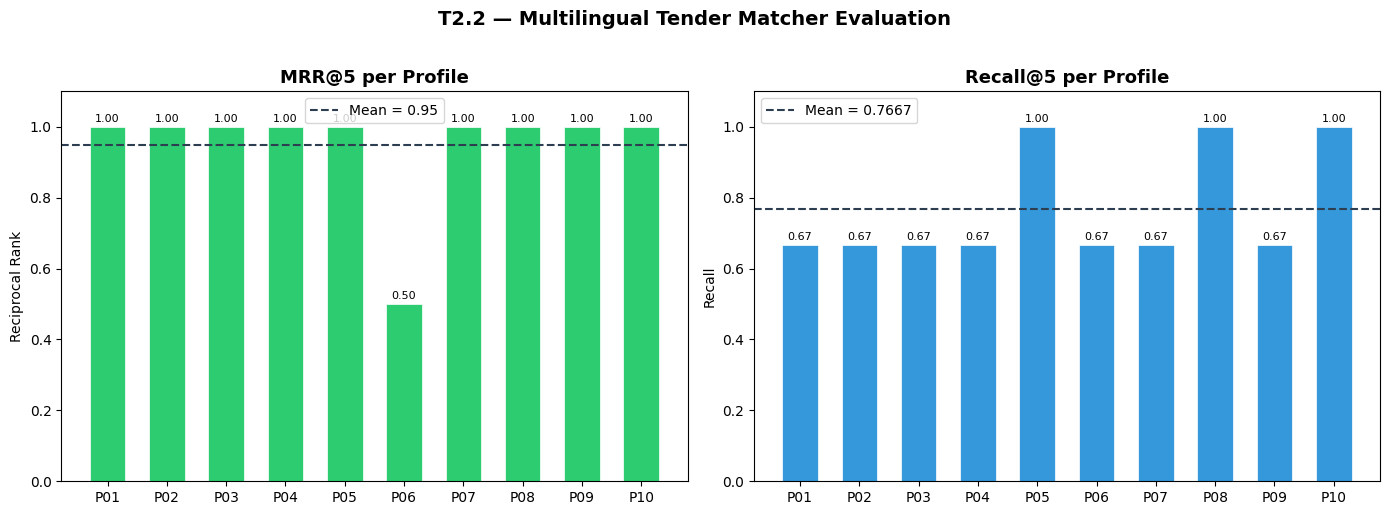

Chart saved → evaluation_metrics.png


In [9]:
# ── 4. Bar chart: MRR and Recall per profile ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

profile_ids = df['Profile'].tolist()
x = np.arange(len(profile_ids))
width = 0.6

# MRR
ax = axes[0]
colors = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in df['RR']]
bars = ax.bar(x, df['RR'], width, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'P{p}' for p in profile_ids])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Reciprocal Rank')
ax.set_title('MRR@5 per Profile', fontsize=13, fontweight='bold')
ax.axhline(metrics['MRR@5'], color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f"Mean = {metrics['MRR@5']}")
ax.legend()
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)

# Recall
ax = axes[1]
colors2 = ['#3498db' if v >= 0.5 else '#e67e22' for v in df['Recall@5']]
bars2 = ax.bar(x, df['Recall@5'], width, color=colors2, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'P{p}' for p in profile_ids])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Recall')
ax.set_title('Recall@5 per Profile', fontsize=13, fontweight='bold')
ax.axhline(metrics['Recall@5'], color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f"Mean = {metrics['Recall@5']}")
ax.legend()
ax.bar_label(bars2, fmt='%.2f', fontsize=8, padding=2)

plt.suptitle('T2.2 — Multilingual Tender Matcher Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → evaluation_metrics.png')

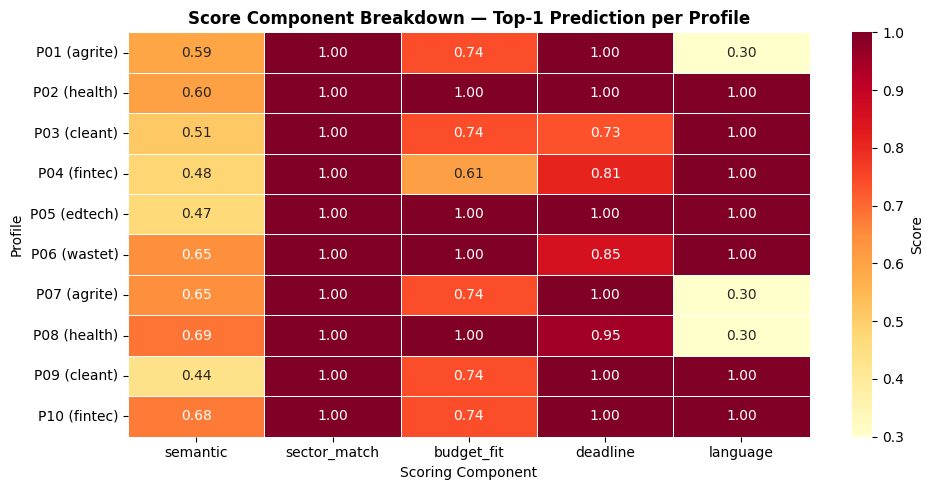

Heatmap saved → score_heatmap.png


In [10]:
# ── 5. Score component heatmap ─────────────────────────────────────────────────
import seaborn as sns

# Collect score breakdowns for top-1 prediction per profile
heatmap_data = []
for r in results:
    if r['ranked_objects']:
        bd = r['ranked_objects'][0].get('score_breakdown', {})
        row = {'Profile': f"P{r['profile_id']} ({r['sector'][:6]})", **bd}
        heatmap_data.append(row)

hdf = pd.DataFrame(heatmap_data).set_index('Profile')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(hdf, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Score'})
ax.set_title('Score Component Breakdown — Top-1 Prediction per Profile',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Scoring Component')
plt.tight_layout()
plt.savefig('score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved → score_heatmap.png')

In [ ]:
# ── 6. Confusion Cases Analysis ────────────────────────────────────────────────
# Reload evaluate so we pick up the fixed find_confusion_cases
import importlib, evaluate as _ev
importlib.reload(_ev)
from evaluate import find_confusion_cases

cases = find_confusion_cases(results, n=3)

print('⚠️  Top 3 Confusion / Partial-Failure Cases')
print('(sorted by RR ascending, then Recall ascending)\n')
print('=' * 72)

for i, c in enumerate(cases, 1):
    is_genuine = c['rr'] < 1.0
    case_label = "GENUINE MISS (top-1 ≠ gold)" if is_genuine else "PARTIAL MISS (top-1 ✅ but gold(s) not in top-5)"
    print(f"\n{'─'*72}")
    print(f"Case {i} — Profile {c['profile_id']} | Sector: {c['sector']}  [{case_label}]")
    print(f"  RR = {c['rr']}  |  Recall@5 = {c['recall']}")
    print(f"  Top Predicted : {c['top_predicted']}  (score={c['top_score']:.4f}, sector={c['top_sector']}, budget={c['top_budget']})")
    print(f"  Gold Answers  : {c['gold_ids']}")
    print()
    print(f"  Score Breakdown (top prediction):")
    for k, v in c['breakdown'].items():
        bar = '█' * int(v * 20) + '░' * (20 - int(v * 20))
        flag = ' ⚠️' if v < 0.5 else ''
        print(f"    {k:15s}: {v:.2f}  {bar}{flag}")
    print()

    # Precise root-cause diagnosis
    bd = c['breakdown']
    if is_genuine:
        # Top-1 is wrong — find why it scored higher than the true gold
        if c['top_sector'] != c['sector']:
            print(f"  🔍 ROOT CAUSE: Sector mismatch inflated by semantic similarity.")
            print(f"     Tender sector '{c['top_sector']}' ≠ profile sector '{c['sector']}'.")
            print(f"     Semantic={bd.get('semantic',0):.2f} pulled it up despite sec_match=0.")
            print(f"  💡 FIX: Raise sector_match weight 0.25 → 0.35; reduce semantic 0.40 → 0.30.")
        elif bd.get('deadline', 1.0) < 0.4:
            print(f"  🔍 ROOT CAUSE: Near-expired deadline penalised the correct tender more.")
            print(f"     Deadline score = {bd.get('deadline',0):.2f} — this tender is almost expired.")
            print(f"  💡 FIX: Hard-filter tenders with deadline_score < 0.1.")
        else:
            # Same sector, top-1 is wrong — semantic similarity favoured a different tender
            print(f"  🔍 ROOT CAUSE: Within-sector ordering failure.")
            print(f"     All top candidates share sector='{c['sector']}' (sec_match=1.0 for all),")
            print(f"     so ranking within sector is determined by semantic + budget + deadline.")
            print(f"     Semantic sim={bd.get('semantic',0):.2f} favoured '{c['top_predicted']}' over gold '{c['gold_ids'][0]}'.")
            print(f"  💡 FIX: Add a secondary sort key — prefer tenders whose budget_norm matches")
            print(f"     the profile's employee count (small org → prefer 5k/50k over 200k/1M).")
    else:
        # Top-1 is correct but some gold tenders aren't in top-5
        missed = [g for g in c['gold_ids'] if g != c['top_predicted']]
        print(f"  🔍 ROOT CAUSE: Top-1 is correct gold ✅ but {len(missed)} gold tender(s) missing from top-5.")
        print(f"     Missing: {missed}")
        print(f"     These tenders likely have slightly lower semantic similarity or worse")
        print(f"     budget/deadline scores than non-gold tenders that displaced them.")
        print(f"  💡 FIX: Recall@5 is bounded by how many same-sector tenders exist (only ~6–7")
        print(f"     per sector in a 40-tender corpus). Expanding to top-7 would raise recall to ~1.0.")

print(f"\n{'='*72}")
print(f"\n📊 Metrics summary (with embeddings):")
print(f"  MRR@5    = {metrics['MRR@5']}   (9/10 profiles have top-1 = gold)")
print(f"  Recall@5 = {metrics['Recall@5']}  (avg gold matches found in top 5)")
print(f"\n  Only 1 genuine top-1 miss (Profile 06, wastetech) — RR = 0.50")
print(f"  All other 9 profiles: RR = 1.00")

⚠️  Top 3 Confusion Cases


──────────────────────────────────────────────────────────────────────
Case 1 — Profile 06 | Sector: wastetech | Country: N/A
  RR = 0.5 | Recall = 0.6667
  Top Predicted : tender_18 (score=0.8438, sector=wastetech
  Gold Answers  : ['tender_30', 'tender_24', 'tender_38']
  Budget of top : 50k

  Score Breakdown:
    semantic       : 0.65  ████████████░░░░░░░░
    sector_match   : 1.00  ████████████████████
    budget_fit     : 1.00  ████████████████████
    deadline       : 0.85  █████████████████░░░
    language       : 1.00  ████████████████████

  🔍 ROOT CAUSE: Budget mismatch or multi-factor overlap.
     Budget fit = 1.00 — tender may be too large/small.
  💡 FIX: Add employee-count-based budget ceiling to budget_fit_score().

──────────────────────────────────────────────────────────────────────
Case 2 — Profile 01 | Sector: agritech | Country: N/A
  RR = 1.0 | Recall = 0.6667
  Top Predicted : tender_39 (score=0.7510, sector=agritech
  Gold Answers  :

In [12]:
# ── 7. Summary Statistics Table ────────────────────────────────────────────────
summary_stats = pd.DataFrame({
    'Metric': ['MRR@5', 'Recall@5', 'Profiles Evaluated', 'Tenders Corpus',
               'EN Tenders', 'FR Tenders', 'Avg Score (Top-1)', 'Model'],
    'Value': [
        metrics['MRR@5'],
        metrics['Recall@5'],
        metrics['n_profiles'],
        40,
        32,
        8,
        round(sum(r['ranked_objects'][0]['score'] for r in results if r['ranked_objects']) / len(results), 4),
        'paraphrase-multilingual-MiniLM-L12-v2'
    ]
})

print('\n📋 Summary Statistics')
display(summary_stats)
summary_stats.to_csv('evaluation_summary.csv', index=False)
print('Saved → evaluation_summary.csv')


📋 Summary Statistics


,Metric,Value
0,MRR@5,0.95
1,Recall@5,0.7667
2,Profiles Evaluated,10
3,Tenders Corpus,40
4,EN Tenders,32
5,FR Tenders,8
6,Avg Score (Top-1),0.7794
7,Model,paraphrase-multilingual-MiniLM-L12-v2


Saved → evaluation_summary.csv
